In [5]:
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (BertTokenizer, BertForSequenceClassification,RobertaTokenizer,RobertaForSequenceClassification,DistilBertTokenizer,DistilBertForSequenceClassification)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:",device)


✅ Using device: cuda


In [6]:
df=pd.read_csv("/content/combined_dataset.csv")
print("✅ Dataset loaded:",df.shape)
print(df.head())
text_col="text"
label_col="label"
texts=df[text_col].tolist()
labels=df[label_col].tolist()

✅ Dataset loaded: (44898, 5)
                                               title  \
0  Britain seeks new ways to detect explosives in...   
1  DEAR ANTI-TRUMP PROTESTERS: “Your Behavior Is ...   
2  KARMA: GAY PASTOR SUES WHOLE FOODS For “Anti-G...   
3  HYSTERICAL! BERNIE SANDERS On Why ‘Very Popula...   
4  Kremlin says Putin ready to welcome any U.S. c...   

                                                text       subject  \
0  LONDON (Reuters) - Britain launched a fund on ...     worldnews   
1   You re carrying Mexican flags while chanting,...     left-news   
2  Too bad for the gay pastor that Whole Foods ha...     left-news   
3  Double standards everywhere!  Socialist Bernie...      politics   
4  MOSCOW (Reuters) - The Kremlin said on Wednesd...  politicsNews   

                date  label  
0  October 19, 2017       1  
1       Nov 10, 2016      0  
2       Apr 20, 2016      0  
3       Nov 19, 2017      0  
4  October 19, 2016       1  


In [7]:
def evaluate_model(model,tokenizer,texts,labels,max_len=128):
    model.eval()
    predictions=[]
    true_labels=[]
    with torch.no_grad():
        for i in range(0,len(texts),16):
            batch_texts=texts[i:i+16]
            batch_labels=labels[i:i+16]
            encoding=tokenizer(batch_texts,truncation=True,padding=True,max_length=max_len,return_tensors="pt").to(device)
            outputs=model(**encoding)
            logits=outputs.logits
            preds=torch.argmax(logits,dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(batch_labels)
    acc=accuracy_score(true_labels,predictions)
    prec=precision_score(true_labels,predictions,average='weighted',zero_division=0)
    rec=recall_score(true_labels,predictions,average='weighted',zero_division=0)
    f1=f1_score(true_labels,predictions,average='weighted',zero_division=0)
    print(classification_report(true_labels,predictions))
    return acc,prec,rec,f1,confusion_matrix(true_labels,predictions)

In [9]:
print("\n🚀 Loading Models...\n")
bert_tokenizer=BertTokenizer.from_pretrained("/content/models/Model/bert_model")
bert_model=BertForSequenceClassification.from_pretrained("/content/models/Model/bert_model").to(device)
roberta_tokenizer=RobertaTokenizer.from_pretrained("/content/models/Model/roberta_model")
roberta_model=RobertaForSequenceClassification.from_pretrained("/content/models/Model/roberta_model").to(device)
distilbert_tokenizer=DistilBertTokenizer.from_pretrained("/content/models/Model/distilbert_model")
distilbert_model=DistilBertForSequenceClassification.from_pretrained("/content/models/Model/distilbert_model").to(device)



🚀 Loading Models...



In [11]:
results={}
print("\n🔹 Evaluating BERT...")
results['BERT']=evaluate_model(bert_model,bert_tokenizer,texts,labels)
print("\n🔹 Evaluating RoBERTa...")
results['RoBERTa']=evaluate_model(roberta_model,roberta_tokenizer,texts,labels)
print("\n🔹 Evaluating DistilBERT...")
results['DistilBERT']=evaluate_model(distilbert_model,distilbert_tokenizer,texts,labels)



🔹 Evaluating BERT...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23481
           1       1.00      1.00      1.00     21417

    accuracy                           1.00     44898
   macro avg       1.00      1.00      1.00     44898
weighted avg       1.00      1.00      1.00     44898


🔹 Evaluating RoBERTa...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23481
           1       1.00      1.00      1.00     21417

    accuracy                           1.00     44898
   macro avg       1.00      1.00      1.00     44898
weighted avg       1.00      1.00      1.00     44898


🔹 Evaluating DistilBERT...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23481
           1       1.00      1.00      1.00     21417

    accuracy                           1.00     44898
   macro avg       1.00      1.00      1.00     44898

In [26]:
results_clean={}
for model_name,metrics in results.items():
    results_clean[model_name]=metrics[:4]
results_df=pd.DataFrame(results_clean,index=['Accuracy','Precision','Recall','F1 Score']).T
print("\n📊 Final Model Comparison:\n")
print(results_df)


📊 Final Model Comparison:

            Accuracy  Precision    Recall  F1 Score
BERT        0.999020   0.999020  0.999020  0.999020
RoBERTa     0.999644   0.999644  0.999644  0.999644
DistilBERT  0.999889   0.999889  0.999889  0.999889


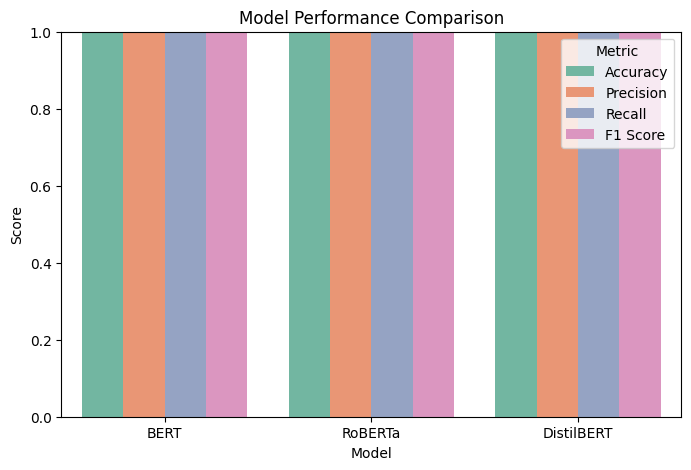

In [27]:
plt.figure(figsize=(8,5))
results_melted=results_df.reset_index().melt(id_vars='index',var_name='Metric',value_name='Score')
results_melted.rename(columns={'index':'Model'},inplace=True)
sns.barplot(x='Model', y='Score',hue='Metric', data=results_melted,palette='Set2')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

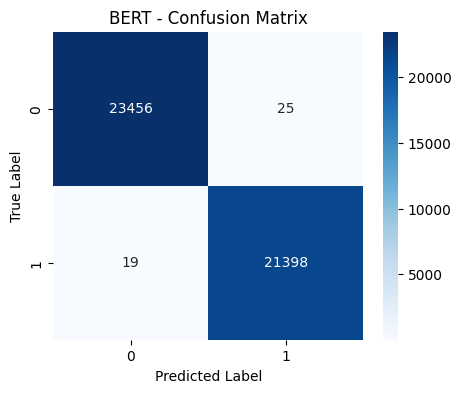

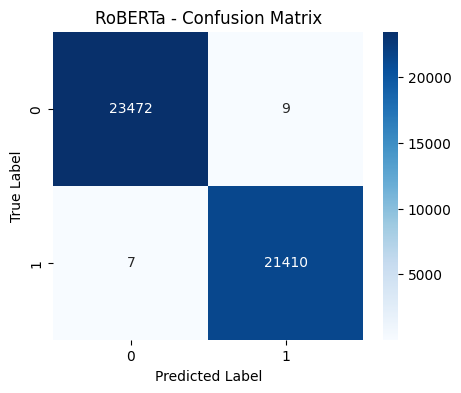

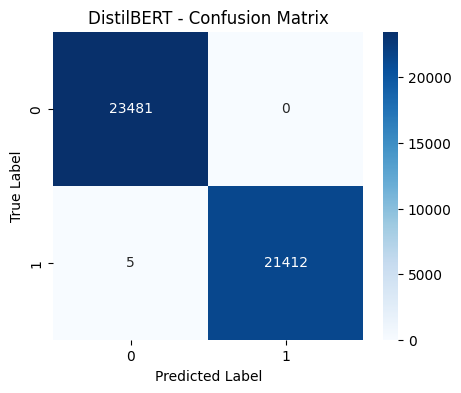

In [28]:
model_names = ["BERT","RoBERTa","DistilBERT"]
for name,(_,_,_,_,cm) in zip(model_names,results.values()):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

✅ Results table saved as model_comparison_results.csv
✅ Bar chart saved as model_comparison_chart.png

📂 All results saved in: /content/results/


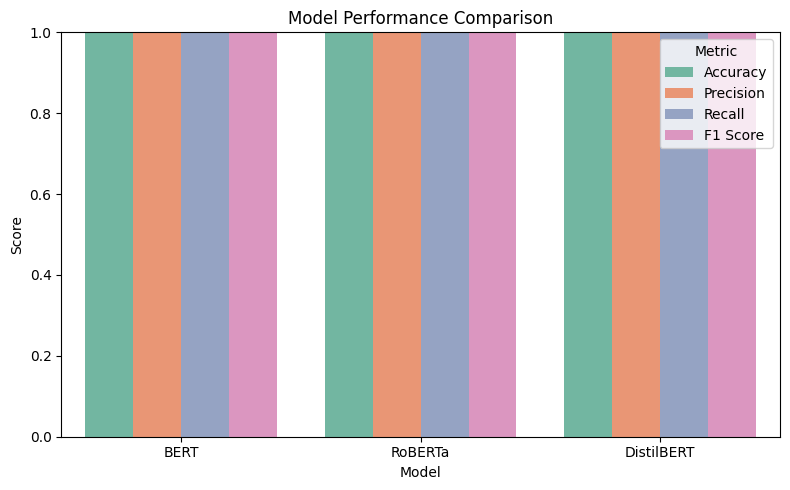

In [30]:
import os
os.makedirs("/content/results",exist_ok=True)
results_df.to_csv("/content/results/model_comparison_results.csv", index=True)
print("✅ Results table saved as model_comparison_results.csv")
plt.figure(figsize=(8,5))
sns.barplot(x='Model',y='Score',hue='Metric',data=results_melted,palette='Set2')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0,1)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("/content/results/model_comparison_chart.png", dpi=300)
print("✅ Bar chart saved as model_comparison_chart.png")
for name,(_,_,_,_,cm) in zip(model_names,results.values()):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f"/content/results/{name}_confusion_matrix.png", dpi=300)
    plt.close()
print("\n📂 All results saved in: /content/results/")
